<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Unsupervised_Learning_in_Python_A_Practical_Guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import warnings
# Suppress DeprecationWarnings from internal libraries
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [12]:
# Install mlxtend (if not already installed)
!pip install mlxtend -q

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from mlxtend.frequent_patterns import apriori, association_rules

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

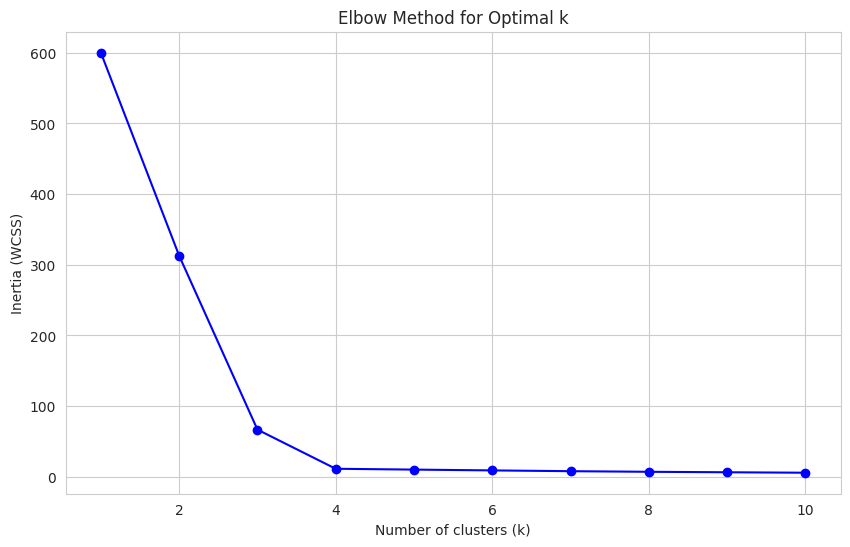

In [13]:
# 1. Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X = StandardScaler().fit_transform(X)  # scaling helps

# 2. Elbow method: compute inertia for k=1..10
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot elbow
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.show()

Silhouette Score for k=4: 0.839


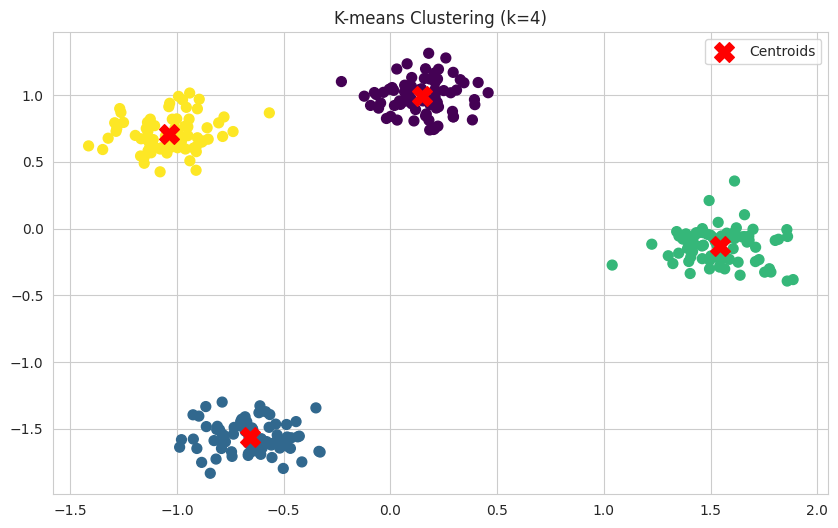

In [14]:
# 3. Fit K-means with optimal k
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, init='k-means++', n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

# 4. Silhouette score
sil = silhouette_score(X, labels)
print(f"Silhouette Score for k={k_opt}: {sil:.3f}")

# 5. Visualize clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=200, c='red', label='Centroids')
plt.title(f'K-means Clustering (k={k_opt})')
plt.legend()
plt.show()

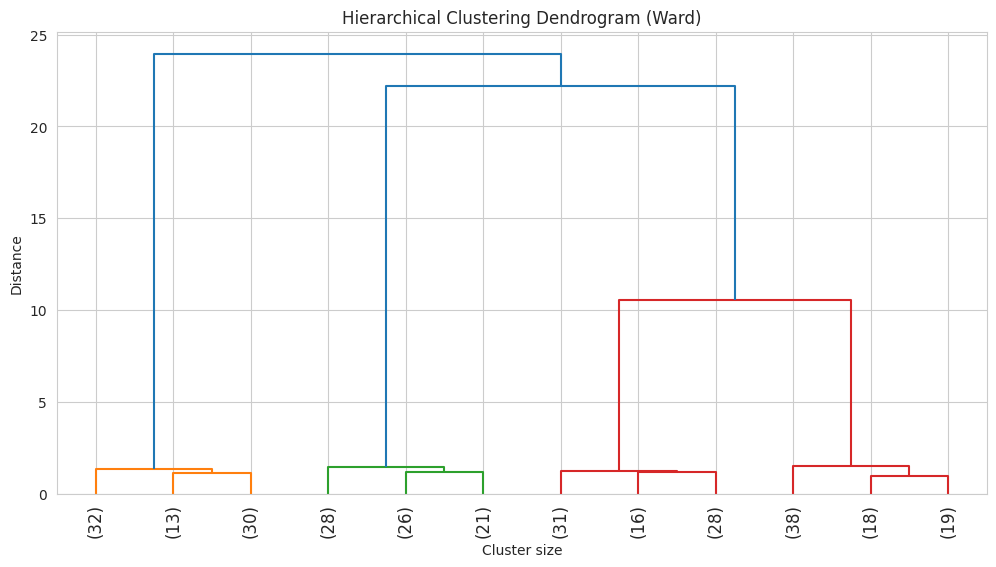

In [15]:
# Use the same scaled data X from Task 1
# Compute linkage matrix for dendrogram
linkage_matrix = linkage(X, method='ward')  # or 'single'

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=12.)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

Linkage=ward: Silhouette = 0.839


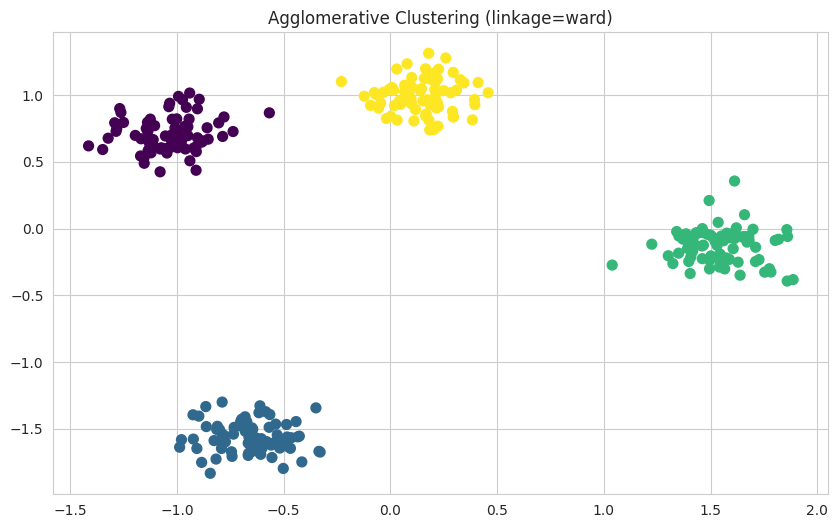

Linkage=single: Silhouette = 0.839


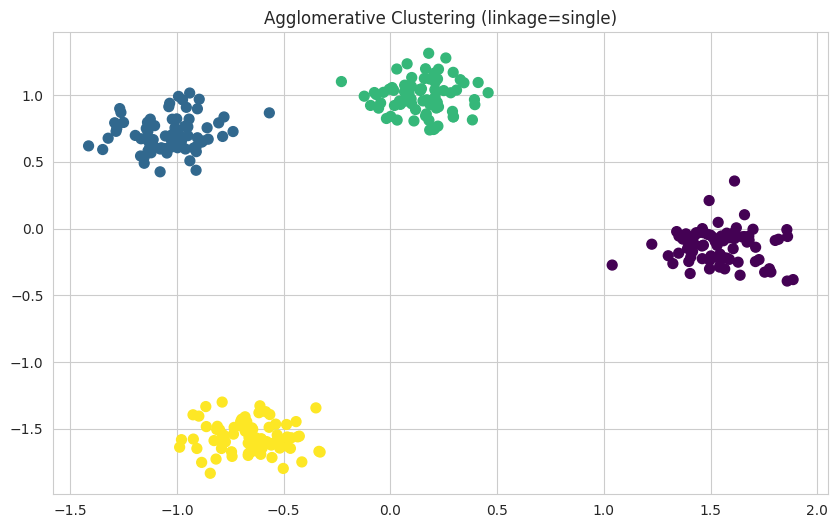

In [16]:
# Fit Agglomerative with Ward and single linkage
for linkage_type in ['ward', 'single']:
    model = AgglomerativeClustering(n_clusters=4, linkage=linkage_type)
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    print(f"Linkage={linkage_type}: Silhouette = {sil:.3f}")
    # Visualize
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    plt.title(f'Agglomerative Clustering (linkage={linkage_type})')
    plt.show()

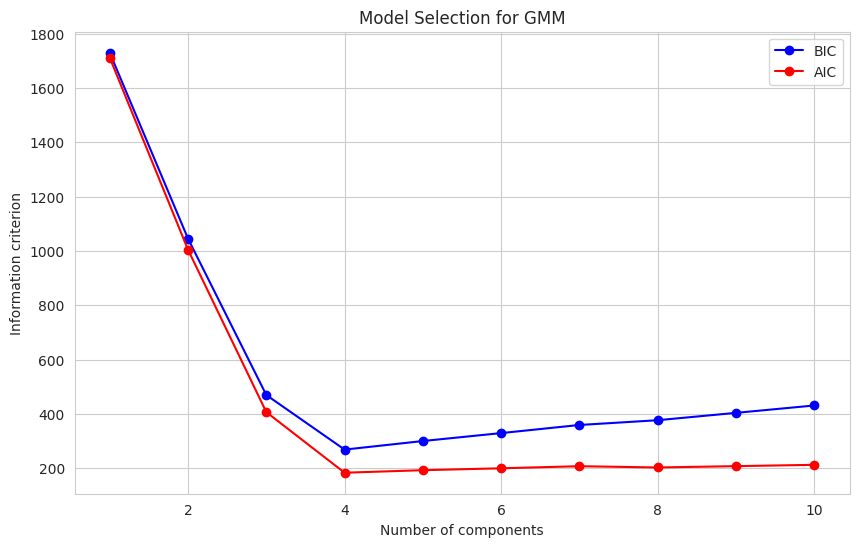

In [17]:
# Use the same data X
# Evaluate BIC for different numbers of components
n_components_range = range(1, 11)
bics = []
aics = []
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))

# Plot BIC/AIC
plt.plot(n_components_range, bics, 'bo-', label='BIC')
plt.plot(n_components_range, aics, 'ro-', label='AIC')
plt.xlabel('Number of components')
plt.ylabel('Information criterion')
plt.title('Model Selection for GMM')
plt.legend()
plt.show()

GMM Silhouette Score (n=4): 0.839


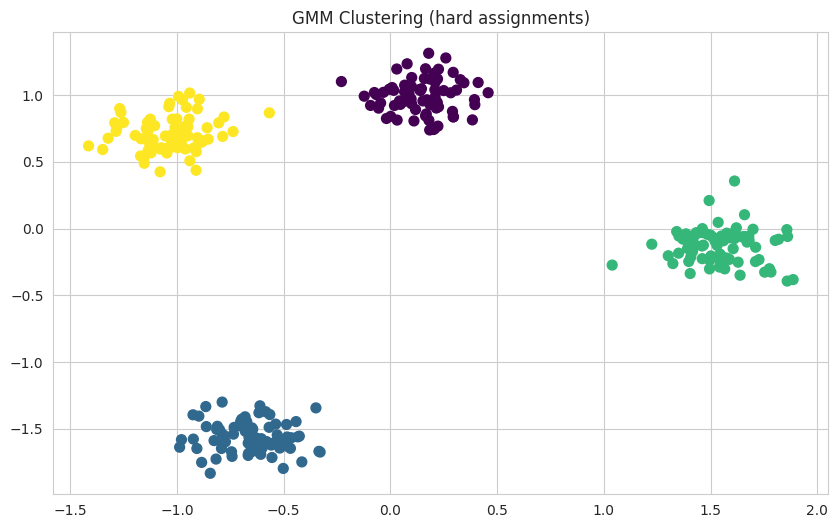

First 5 points' soft probabilities:
 [[2.83621071e-021 1.27865982e-078 3.19647737e-067 1.00000000e+000]
 [1.36704532e-022 3.24706745e-083 4.90447807e-071 1.00000000e+000]
 [1.00000000e+000 3.76711511e-107 1.13374889e-024 1.28002769e-017]
 [4.70879433e-088 1.00000000e+000 2.36574397e-069 1.19620562e-065]
 [1.48158694e-028 5.66109097e-078 1.60209181e-077 1.00000000e+000]]


In [18]:
# Fit GMM with optimal number (e.g., 4)
gmm_opt = GaussianMixture(n_components=4, random_state=42)
gmm_opt.fit(X)
labels = gmm_opt.predict(X)          # hard assignment
probs = gmm_opt.predict_proba(X)     # soft probabilities

# Silhouette score (on hard assignments)
sil = silhouette_score(X, labels)
print(f"GMM Silhouette Score (n=4): {sil:.3f}")

# Visualize hard assignments
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('GMM Clustering (hard assignments)')
plt.show()

# Show first 5 points' probabilities
print("First 5 points' soft probabilities:\n", probs[:5])

In [19]:
# Sample transactional data (binary encoded)
dataset = [['Milk', 'Eggs', 'Bread'],
           ['Milk', 'Butter'],
           ['Eggs', 'Bread', 'Butter'],
           ['Milk', 'Eggs', 'Bread', 'Butter'],
           ['Milk', 'Eggs'],
           ['Bread', 'Butter'],
           ['Milk', 'Bread'],
           ['Eggs', 'Butter'],
           ['Milk', 'Eggs', 'Butter'],
           ['Bread']]

# Convert to one-hot encoded DataFrame
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with support >= 0.4
frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
print("Frequent itemsets (support >= 0.4):\n", frequent_itemsets)

# Generate rules with confidence >= 0.6
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
# Add lift
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print("\nAssociation Rules:\n", rules)

Frequent itemsets (support >= 0.4):
    support        itemsets
0      0.6         (Bread)
1      0.6        (Butter)
2      0.6          (Eggs)
3      0.6          (Milk)
4      0.4  (Eggs, Butter)
5      0.4    (Eggs, Milk)

Association Rules:
   antecedents consequents  support  confidence      lift
0      (Eggs)    (Butter)      0.4    0.666667  1.111111
1    (Butter)      (Eggs)      0.4    0.666667  1.111111
2      (Eggs)      (Milk)      0.4    0.666667  1.111111
3      (Milk)      (Eggs)      0.4    0.666667  1.111111


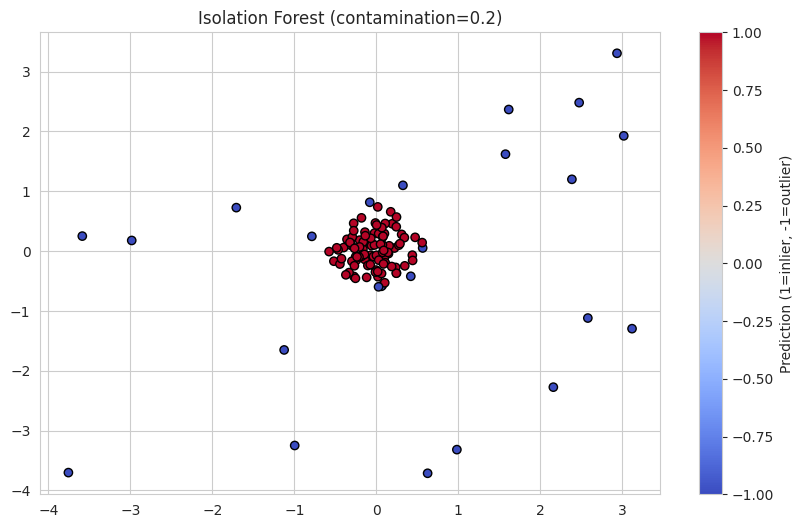

Anomaly scores (first 10): [0.05565966 0.03607762 0.0700022  0.00600434 0.06027815 0.05993985
 0.00031082 0.01974027 0.05975642 0.02922328]
Predicted labels (first 10): [1 1 1 1 1 1 1 1 1 1]
Number of detected outliers: 24


In [20]:
# Generate a dataset with some outliers
X_train = 0.3 * np.random.randn(100, 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.vstack([X_train, X_outliers])

# Fit Isolation Forest
contamination = 0.2  # expected proportion of outliers
iso_forest = IsolationForest(contamination=contamination, random_state=42)
preds = iso_forest.fit_predict(X)          # 1 for inliers, -1 for outliers
scores = iso_forest.decision_function(X)    # anomaly score (lower = more anomalous)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='coolwarm', edgecolors='k')
plt.title(f'Isolation Forest (contamination={contamination})')
plt.colorbar(label='Prediction (1=inlier, -1=outlier)')
plt.show()

# Show anomaly scores
print("Anomaly scores (first 10):", scores[:10])
print("Predicted labels (first 10):", preds[:10])

# Identify outliers based on threshold (e.g., negative scores)
threshold = np.percentile(scores, 100 * contamination)   # lower percentile
outliers = scores < threshold
print(f"Number of detected outliers: {np.sum(outliers)}")